In [12]:
import pickle
from pprint import pprint
import os
import dask.dataframe as ddf
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from lightgbm import LGBMClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import (
    PartialDependenceDisplay,
    partial_dependence,
    permutation_importance,
)
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import (
    GridSearchCV,
    RandomizedSearchCV,
    RepeatedStratifiedKFold,
    StratifiedKFold,
    train_test_split,
)

from RF_operations import *

In [13]:
# split test and validation datasets
exclude_columns = []
pred_attr = "DGWS"
output_dir = "/home/terry/working/groundwater/grace/deep_groundwater/figure/random_forest/project/RF/model/Predictors/"
csv_dir = "/home/terry/working/groundwater/grace/deep_groundwater/figure/random_forest/project/RF/model/Predictors/total.csv"
x_train, x_test, y_train, y_test, predictor_name_dict = split_train_test_ratio(
    predictor_csv=csv_dir,
    exclude_columns=[],
    pred_attr="DGWS",
    test_size=0.3,
    random_state=0,
    outdir=output_dir,
)

Dropping Columns- []
Predictors: Index(['crop', 'rain', 'irrigation', 'salt', 'distance', 'pop', 'AI',
       'building', 'CGI', 'clay', 'soil_m', 'tem'],
      dtype='object')


In [3]:
## k-fold parameters
global classifier
optimized_param_dict = hyperparameter_optimization(
    x_train,
    y_train,
    model="rf",
    folds=10,
    n_iter=1,
    random_search=True,
    repeatedstratified=False,
)

Classifier Name: rf
{'max_depth': [8, 12, 13, 14],
 'max_features': [6, 7, 9, 10],
 'min_samples_leaf': [0.0005, 1e-05, 0.001, 6, 12, 20, 25],
 'min_samples_split': [6, 7, 8, 10],
 'n_estimators': [100, 200, 300, 400, 500]}
Fitting 10 folds for each of 1 candidates, totalling 10 fits


best parameters for macro f1 value  

{'max_depth': 13,
 'max_features': 10,
 'min_samples_leaf': 20,
 'min_samples_split': 8,
 'n_estimators': 400}


mean_test_macro_f1_score 0.88
mean_train_macro_f1_score 0.9


In [3]:
## model training
# n_estimators = optimized_param_dict["n_estimators"]
# max_depth = optimized_param_dict["max_depth"]
# max_features = optimized_param_dict["max_features"]
# min_samples_leaf = optimized_param_dict["min_samples_leaf"]
# min_samples_split = optimized_param_dict["min_samples_split"]
classifier = RandomForestClassifier(
    n_estimators=400,
    max_features=10,
    min_samples_leaf=20,
    min_samples_split=8,
    max_depth=13,
    max_samples=None,
    max_leaf_nodes=None,
    random_state=0,
    bootstrap=True,
    class_weight="balanced",
    n_jobs=-1,
    oob_score=True,
)
classifier = classifier.fit(x_train, y_train)

                         Predicted                            
                       <16.3 mm/yr 16.3-42.5 mm/yr >42.5 mm/yr
Actual <16.3 mm/yr           60936            3728         210
       16.3-42.5 mm/yr         808           19190        1627
       >42.5 mm/yr              15             704       12368 

                         Predicted                            
                       <16.3 mm/yr 16.3-42.5 mm/yr >42.5 mm/yr
Actual <16.3 mm/yr           25950            1762          92
       16.3-42.5 mm/yr         544            7901         823
       >42.5 mm/yr              13             479        5117 

Test confusion matrix saved
0.91 

0.91 

0.91 

1           rain
6             AI
11           tem
10        soil_m
4       distance
3           salt
5            pop
9           clay
7       building
0           crop
2     irrigation
8            CGI
Name: feature_names, dtype: object
[0.00628628 0.36298178 0.00577201 0.05992564 0.0719565  0.05053707
 0.1747147 

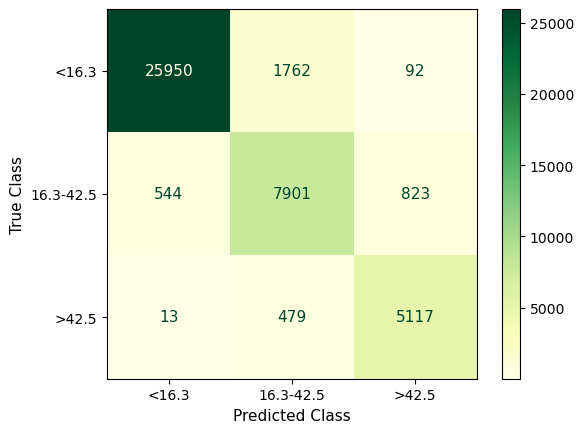

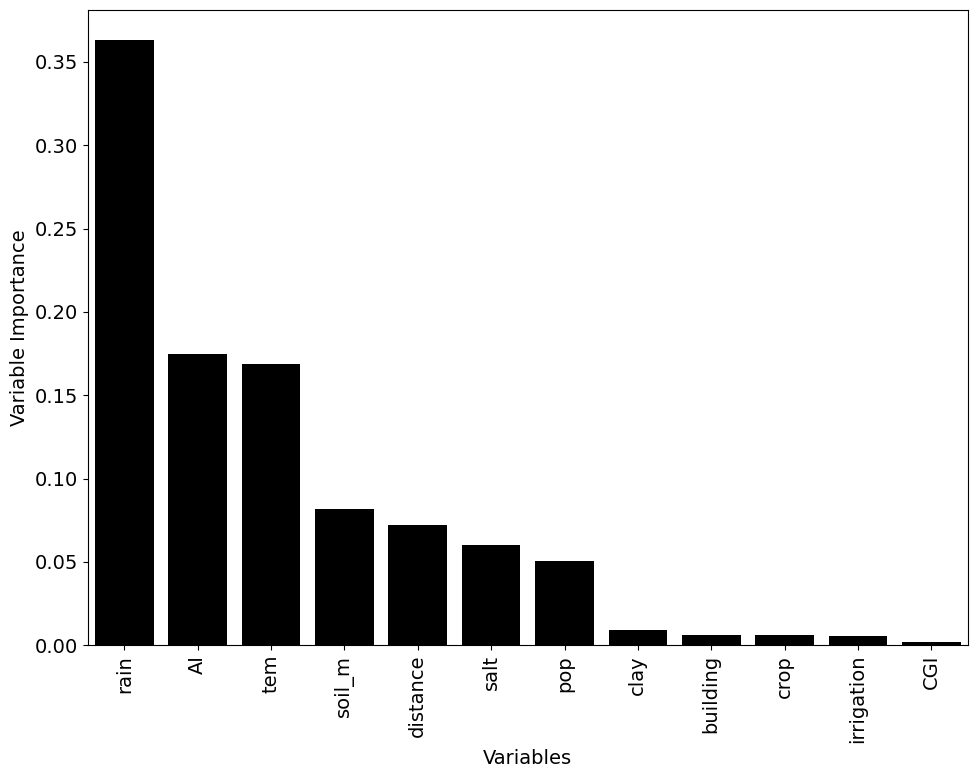

In [4]:
## accuracy evaluation
y_train_pred = classifier.predict(x_train)
y_pred = classifier.predict(x_test)
cm_train = confusion_matrix(y_train, y_train_pred)
cm_test = confusion_matrix(y_test, y_pred)

column_labels = [
    np.array(["Predicted", "Predicted", "Predicted"]),
    np.array(["<16.3 mm/yr", "16.3-42.5 mm/yr", ">42.5 mm/yr"]),
]
index_labels = [
    np.array(["Actual", "Actual", "Actual"]),
    np.array(["<16.3 mm/yr", "16.3-42.5 mm/yr", ">42.5 mm/yr"]),
]
cm_df_train = pd.DataFrame(cm_train, columns=column_labels, index=index_labels)
cm_df_test = pd.DataFrame(cm_test, columns=column_labels, index=index_labels)
print(cm_df_train, "\n")
print(cm_df_test, "\n")

font = 11
label = np.array(["<16.3", "16.3-42.5", ">42.5"])
disp = ConfusionMatrixDisplay(cm_test, display_labels=label)
disp.plot(cmap="YlGn")
for labels in disp.text_.ravel():
    labels.set_fontsize(font)
disp.ax_.set_ylabel("True Class", fontsize=font)
disp.ax_.set_xlabel("Predicted Class", fontsize=font)
plot_name = 'accuracy.png'
plt.savefig((plot_name), dpi=400)
print("Test confusion matrix saved")

micro_precision = round(precision_score(y_test, y_pred, average="micro"), 2)
micro_recall = round(recall_score(y_test, y_pred, average="micro"), 2)
micro_f1 = round(f1_score(y_test, y_pred, average="micro"), 2)
print(micro_precision, "\n")
print(micro_recall, "\n")
print(micro_f1, "\n")

### important plot
predictor_dict = {
    0: "crop",
    1: "rain",
    2: "irrigation",
    3: "salt",
    4: "distance",
    5: "pop",
    6: "DGWS",
}
x_train_df = pd.DataFrame(x_train)
x_train_df = x_train_df.rename(columns=predictor_dict)
col_labels = np.array(x_train_df.columns)
importance = np.array(classifier.feature_importances_)
imp_dict = {"feature_names": col_labels, "feature_importance": importance}
imp_df = pd.DataFrame(imp_dict)
imp_df.sort_values(by=["feature_importance"], ascending=False, inplace=True)
plt.figure(figsize=(10, 8))
plt.rcParams["font.size"] = 14
print(imp_df["feature_names"])
sns.barplot(x=imp_df["feature_names"], y=imp_df["feature_importance"], color="black")
plt.xticks(rotation=90)
plt.ylabel("Variable Importance")
plt.xlabel("Variables")
plt.tight_layout()
print(importance)
# plt.savefig((accuracy_dir + '/' + predictor_imp_keyword + '_pred_importance.png'), dpi=600)
# print('Feature importance plot saved')

<Figure size 1000x800 with 0 Axes>

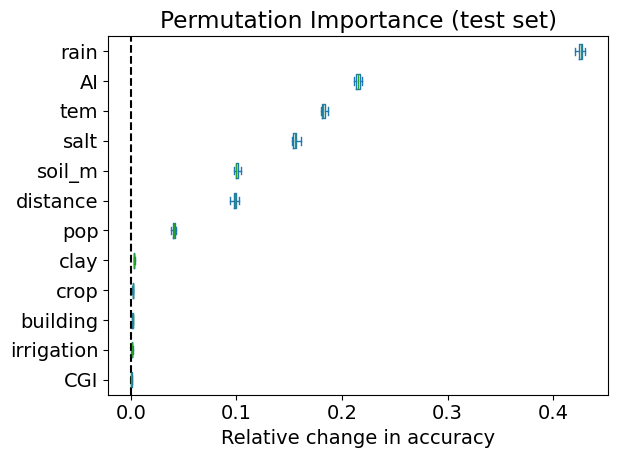

In [5]:
## permutation importance
from sklearn.metrics import f1_score, make_scorer

predictor_cols = pd.read_csv(
    "/home/terry/working/groundwater/grace/deep_groundwater/figure/random_forest/project/RF/model/Predictors/X_test.csv"
).columns
f1_macro = make_scorer(f1_score, average="macro")
# Permutation importance on test set
result_test = permutation_importance(
    classifier,
    x_test,
    y_test,
    n_repeats=30,
    random_state=0,
    n_jobs=-1,
    scoring=f1_macro,
)

sorted_importances_idx = result_test.importances_mean.argsort()
importances = pd.DataFrame(
    result_test.importances[sorted_importances_idx].T,
    columns=predictor_cols[sorted_importances_idx],
)
plt.figure(figsize=(10, 8))
ax = importances.plot.box(vert=False, whis=10)
ax.set_title("Permutation Importance (test set)")
ax.axvline(x=0, color="k", linestyle="--")
ax.set_xlabel("Relative change in accuracy")
ax.figure.tight_layout()
print(np.mean(importances,axis=0))

Exception ignored in: <function ResourceTracker.__del__ at 0x7a11d8fa0680>
Traceback (most recent call last):
  File "/home/terry/anaconda3/envs/GWS/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/home/terry/anaconda3/envs/GWS/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/home/terry/anaconda3/envs/GWS/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x74cc77998680>
Traceback (most recent call last):
  File "/home/terry/anaconda3/envs/GWS/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/home/terry/anaconda3/envs/GWS/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/home/terry/anaconda3/envs/GWS/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Ex

0.5033375185527806


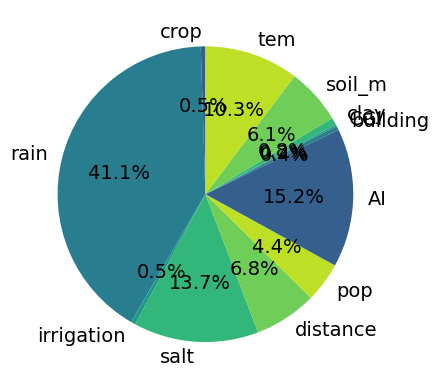

In [6]:
## shap
import shap

feature_names = [
    "crop",
    "rain",
    "irrigation",
    "salt",
    "distance",
    "pop",
    "AI",
    "building",
    "CGI",
    "clay",
    "soil_m",
    "tem",
]
explainer = shap.TreeExplainer(classifier)
shap_values = explainer.shap_values(x_test)
#shape_class3 = shap_values[:, :, 2]
shape_class3=np.abs(shap_values).mean(axis=2)
shap_importance = np.abs(shape_class3).mean(axis=0)
total_importance = shap_importance.sum()
contribution_pct = (shap_importance / total_importance) * 100
results_df = pd.DataFrame(
    {
        "Feature": feature_names,
        "Contribution_%": contribution_pct,
    }
)

colors = plt.cm.viridis(np.linspace(0.3, 0.9, 6))
wedges, texts, autotexts = plt.pie(
    results_df["Contribution_%"],
    labels=results_df["Feature"],
    autopct="%1.1f%%",
    startangle=90,
    colors=colors,
)
plt.savefig("shap.pdf", format="pdf", dpi=600, bbox_inches="tight")
print(contribution_pct[0])

[0.00269057 0.18772846 0.00230582 0.07340287 0.03763676 0.01314782
 0.0590409  0.00119442 0.00094258 0.00232083 0.01785101 0.04119414]


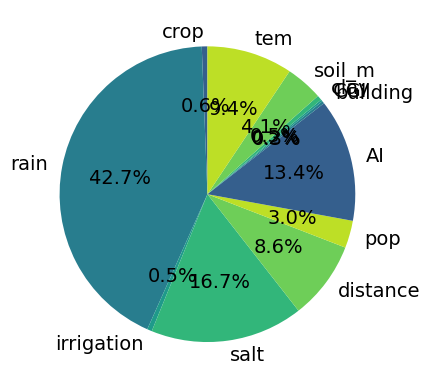

In [11]:
shape_class3=np.abs(shap_values).mean(axis=2)
shape_class3=shap_values[:,:,2]
shap_importance = np.abs(shape_class3).mean(axis=0)
total_importance = shap_importance.sum()
contribution_pct = (shap_importance / total_importance) * 100
results_df = pd.DataFrame(
    {
        "Feature": feature_names,
        "Contribution_%": contribution_pct,
    }
)

colors = plt.cm.viridis(np.linspace(0.3, 0.9, 6))
wedges, texts, autotexts = plt.pie(
    results_df["Contribution_%"],
    labels=results_df["Feature"],
    autopct="%1.1f%%",
    startangle=90,
    colors=colors,
)
print(shap_importance)
np.savetxt('shape.csv',shap_importance,delimiter=',',fmt='%.3f')

## print(result_test.importances_mean.sum())

In [8]:
print(np.abs(importances).mean(axis=0))
#print(result_test)

CGI           0.000485
irrigation    0.001221
building      0.001568
crop          0.001826
clay          0.003167
pop           0.041005
distance      0.098594
soil_m        0.100213
salt          0.155589
tem           0.182250
AI            0.215151
rain          0.426050
dtype: float64


In [17]:
micro_precision = precision_score(y_test, y_pred, average=None)
micro_recall = recall_score(y_test, y_pred, average=None)
micro_f1 = f1_score(y_test, y_pred, average=None)
print(micro_precision, "\n")
print(micro_recall, "\n")
print(micro_f1, "\n")

[0.97898668 0.77903767 0.84830902] 

[0.93331895 0.85250324 0.91228383] 

[0.95560752 0.81411643 0.8791341 ] 

